# Detector de mudança de conceito (`CalibratedKSDetector`) — equipamentos B-8802B e B-4064A

O detector adotado no monitor de produção (M6), testado nos dois equipamentos em que já temos
mudanças de conceito conhecidas.

**Como funciona** (código em `src/transpetro_modelos/drift/detectors.py`):
1. **Calibração** no período normal: para cada sensor, guarda uma amostra de referência e define o
   limiar como o maior estatístico D do teste KS entre cada dia da referência e a referência inteira.
2. **Uso**: a cada dia de operação, compara o dia com a referência, sensor por sensor. Um dia é
   "diferente" quando algum sensor passa do seu limiar.
3. **Persistência**: dispara quando **3 dos últimos 5 dias** são diferentes, e informa por quais sensores.

**O que medimos em cada caso**: atraso do 1º disparo depois de uma mudança conhecida e disparos em
períodos sem mudança (falsos alarmes).

Nas figuras, a curva é o **pior sensor do dia** dividido pelo limiar dele: acima de 1 = dia diferente.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from transpetro_modelos.drift.detectors import CalibratedKSDetector
from transpetro_modelos.drift import monitor as mon
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.preprocessing import run_preprocessing

DEP = PROJECT_ROOT / "deploy_v2/Transpetro"
RAW_8802 = DEP / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv"
B_2022 = DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE"        # modelo antigo
B_2025 = DEP / "B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"   # modelo em produção

def atraso(disparos, mudanca, idx):
    """1º disparo depois da mudança: (instante, sensores, dias, amostras) ou None."""
    depois = [(t, s) for t, s in disparos if t >= mudanca]
    if not depois: return None
    t, s = depois[0]
    return t, s, (t - mudanca).total_seconds() / 86400, int(((idx >= mudanca) & (idx <= t)).sum())

def plot_caso(det, d_diario, disparos, titulo, mudanca=None, ini=None, fim=None):
    razao = (d_diario / pd.Series(det.d_crit, index=det.feature_names)).max(axis=1)
    if ini is not None or fim is not None: razao = razao[ini:fim]
    buraco = razao.index.to_series().diff() > pd.Timedelta(days=3)          # parada longa: quebra a linha
    razao = pd.concat([razao, pd.Series(np.nan, index=razao.index[buraco] - pd.Timedelta(seconds=1))]).sort_index()
    plt.figure(figsize=(12, 3.8))
    plt.plot(razao.index, razao.values, linewidth=0.9, label="D do dia ÷ limiar (pior sensor)")
    plt.axhline(1, color="gray", linestyle="--", linewidth=1, label="limiar")
    if mudanca is not None:
        plt.axvline(mudanca, color="black", linewidth=1.5, label=f"mudança conhecida ({mudanca:%d/%m/%Y})")
    vis = [(t, s) for t, s in disparos if (ini is None or t >= pd.Timestamp(ini)) and (fim is None or t <= pd.Timestamp(fim))]
    for i, (t, s) in enumerate(vis):
        plt.axvline(t, color="red", linestyle="--", linewidth=1.2,
                    label=f"disparo do detector ({len(vis)} no período)" if i == 0 else None)
    plt.ylabel("D ÷ limiar"); plt.title(titulo); plt.legend(loc="upper right", fontsize=8); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
print("ok")

ok


## B-8802B

Dado de operação de jan/2025 a ago/2026 (5 min), 5 sensores. O pré-processamento é o mesmo do
pacote de deploy (filtro de bomba operando, reamostragem, remoção de transientes).

### Caso 1 — drift real: o modelo de 2022 lendo o dado de 2025–26

Referência = período normal de 2022 (é o `drift_ref.json` do bundle antigo). A mudança conhecida é o
início do dado novo (01/01/2025): o equipamento passou por reparo e opera numa faixa de regimes mais ampla.

1º disparo: 05/01/2025 05:05 — 4.2 dias após a mudança (1152 amostras) — via ['Vibração Bomba LA']
disparos na série inteira: 88 (o modelo antigo nunca volta a ser adequado; cada disparo é uma re-detecção)


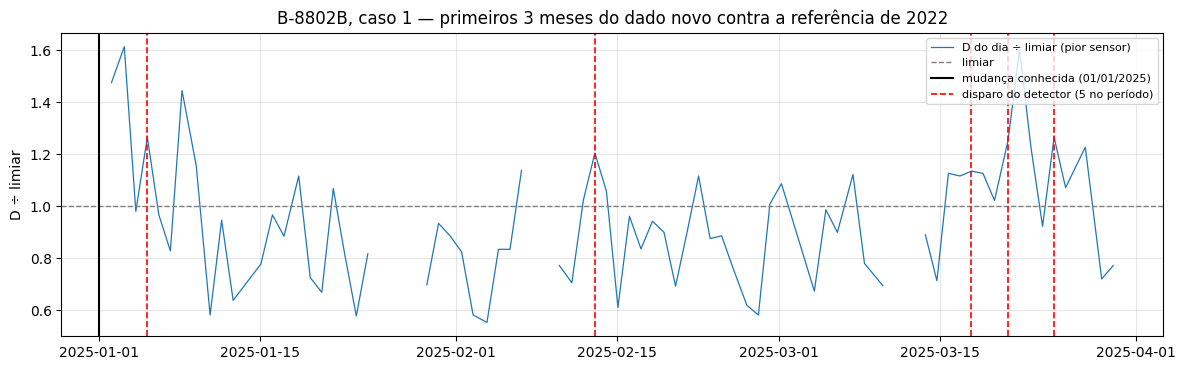

In [2]:
det = CalibratedKSDetector.from_drift_ref(B_2022 / "drift_ref.json")
serie = mon._temporal_steps(B_2022, mon.si_carregar(B_2022, RAW_8802))
d_diario, disparos = det.scan(serie)
mudanca = pd.Timestamp("2025-01-01")
t, s, dias, n = atraso(disparos, mudanca, serie.index)
print(f"1º disparo: {t:%d/%m/%Y %H:%M} — {dias:.1f} dias após a mudança ({n} amostras) — via {s}")
print(f"disparos na série inteira: {len(disparos)} (o modelo antigo nunca volta a ser adequado; cada disparo é uma re-detecção)")
plot_caso(det, d_diario, disparos, "B-8802B, caso 1 — primeiros 3 meses do dado novo contra a referência de 2022",
          mudanca, ini="2025-01-01", fim="2025-04-01")

### Caso 2 — modelo em produção nos próprios dados (2025–26)

Referência = 2025 inteiro (o `drift_ref.json` do bundle em produção). Não há mudança conhecida;
em 2026 existe uma deriva lenta de temperatura já identificada pelo monitor (indicador M5).

disparo: 19/05/2025 15:55 via ['Vibração Bomba LNA']
disparo: 22/05/2025 19:15 via ['Vibração Bomba LNA']
disparo: 27/06/2026 04:05 via ['Temperatura Bomba LA']


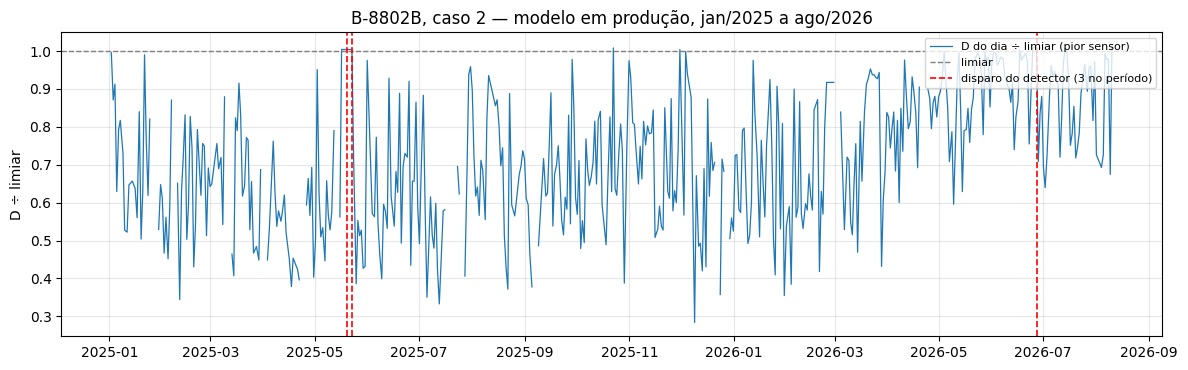

In [3]:
det = CalibratedKSDetector.from_drift_ref(B_2025 / "drift_ref.json")
serie_p = mon._temporal_steps(B_2025, mon.si_carregar(B_2025, RAW_8802))
d_diario, disparos = det.scan(serie_p)
for t, s in disparos: print(f"disparo: {t:%d/%m/%Y %H:%M} via {s}")
plot_caso(det, d_diario, disparos, "B-8802B, caso 2 — modelo em produção, jan/2025 a ago/2026")

### Caso 3 — controle sem drift, fora da calibração

O caso 2 usa a própria referência como parte da série. Aqui o teste é mais honesto: calibramos em
jan–jun/2025 e varremos jul–dez/2025, período em que sabidamente nada mudou. Todo disparo é falso.

referência: 40531 amostras | varredura: 42460 amostras | falsos disparos: 0


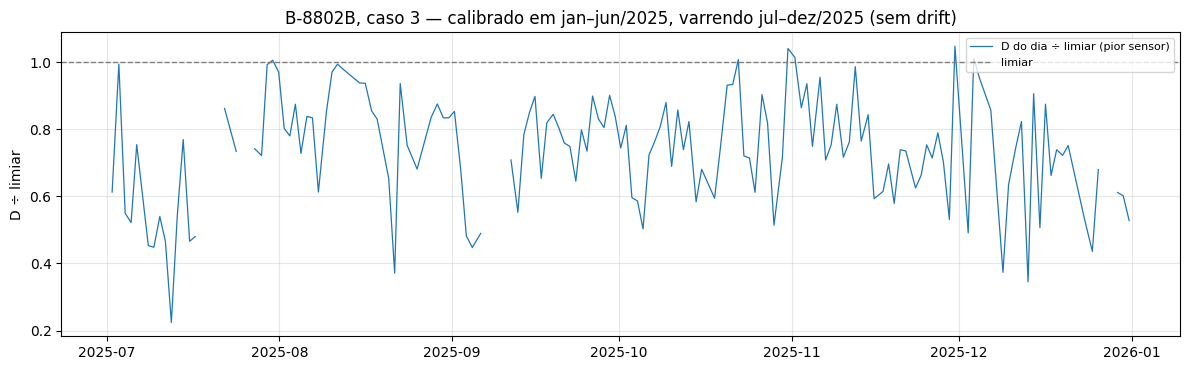

In [4]:
ref = serie_p["2025-01-01":"2025-06-30"]; varredura = serie_p["2025-07-01":"2025-12-31"]
det_c = CalibratedKSDetector(ref, feature_names=list(serie_p.columns))
d_diario, disparos = det_c.scan(varredura)
print(f"referência: {len(ref)} amostras | varredura: {len(varredura)} amostras | falsos disparos: {len(disparos)}")
plot_caso(det_c, d_diario, disparos, "B-8802B, caso 3 — calibrado em jan–jun/2025, varrendo jul–dez/2025 (sem drift)")

### Por que "3 de 5" e não "3 dias seguidos"

No drift real, os dias diferentes vêm intercalados (diferente, diferente, normal, diferente...). Com a
regra de dias seguidos, o atraso depende de onde cada "dia" começa. Abaixo, o caso 1 e o controle do
caso 3 repetidos com 24 alinhamentos diferentes da janela diária (deslocando o início de 1 em 1 hora).

In [5]:
ref_2022 = json.loads((B_2022 / "drift_ref.json").read_text())
linhas = []
for regra, n_win in [("3 dias seguidos", None), ("3 dos últimos 5", 5)]:
    atrasos, falsos = [], []
    for off in range(0, 288, 12):
        d = CalibratedKSDetector.from_drift_ref(ref_2022); d.persistence_window = n_win
        _, f = d.scan(serie.iloc[off:])
        a = atraso(f, mudanca, serie.index); atrasos.append(a[2] if a else np.nan)
        e = CalibratedKSDetector(window_size=288, k_consecutive=3, persistence_window=n_win,
                                 feature_names=det_c.feature_names, samples=det_c.samples, d_crit=det_c.d_crit)
        falsos.append(len(e.scan(varredura.iloc[off:])[1]))
    atrasos = np.array(atrasos)
    linhas.append({"regra": regra, "atraso mediano (dias)": np.nanmedian(atrasos), "melhor caso": np.nanmin(atrasos),
                   "pior caso": np.nanmax(atrasos), "falsos no controle (máx. entre alinhamentos)": max(falsos)})
pd.DataFrame(linhas).set_index("regra").round(1)

,atraso mediano (dias),melhor caso,pior caso,falsos no controle (máx. entre alinhamentos)
regra,,,,
3 dias seguidos,3.9,3.4,75.7,0
3 dos últimos 5,3.9,3.4,8.4,0


## B-4064A

Sem modelo: o detector roda direto nos 8 sensores (dado horário, janela de 24 amostras = 1 dia).
Dois eventos conhecidos: a **falha** em 30/08/2024 (rampa de ~2 dias) e a **volta do reparo** em
14/01/2025, quando o mancal LNA passou a operar ~20 °C acima (novo normal, confirmado pela operação).

In [6]:
cfg = EQUIPMENT_CONFIGS["B-4064A-prod"]
raw4 = pd.read_feather(PROJECT_ROOT / "Dados-novos/B-4064A_novos.feather")
if "Timestamp" in raw4.columns: raw4 = raw4.set_index("Timestamp"); raw4.index = pd.to_datetime(raw4.index)
serie4, _, _ = run_preprocessing(raw4.sort_index(), cfg.pre_split_steps)
FALHA, VOLTA = pd.Timestamp("2024-08-30 07:58"), pd.Timestamp("2025-01-14 12:00")
print(f"{len(serie4)} amostras horárias de {serie4.index.min():%d/%m/%Y} a {serie4.index.max():%d/%m/%Y} | sensores: {list(serie4.columns)}")

11694 amostras horárias de 01/01/2024 a 27/03/2026 | sensores: ['Corrente', 'Pressão Descarga', 'Pressão Sucção', 'Temperatura Bomba LA', 'Temperatura Bomba LNA', 'Temperatura Motor LA', 'Temperatura Motor LNA', 'Vibração Bomba LNA']


### Caso 4a — a falha (rampa de ~2 dias antes de 30/08/2024)

Referência = jan a 20/ago/2024. Varremos de 21/ago até a falha. Esperado: o detector **não** dispara,
porque a rampa dura menos que os 3 dias de persistência exigidos (falha é trabalho do modelo de anomalia).

disparos até a falha: 0 | dias acima do limiar na rampa: 2 de 7


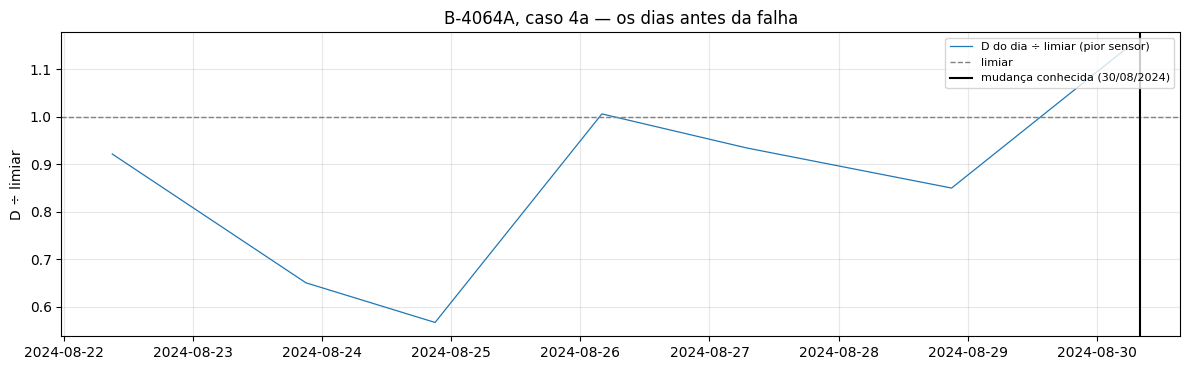

In [7]:
det4 = CalibratedKSDetector(serie4[:"2024-08-20"], window_size=24)
d_diario, disparos = det4.scan(serie4["2024-08-21":FALHA])
razao = (d_diario / pd.Series(det4.d_crit, index=det4.feature_names)).max(axis=1)
print(f"disparos até a falha: {len(disparos)} | dias acima do limiar na rampa: {int((razao > 1).sum())} de {len(razao)}")
plot_caso(det4, d_diario, disparos, "B-4064A, caso 4a — os dias antes da falha", FALHA)

### Caso 4b — a volta do reparo (novo normal a partir de 14/01/2025)

Mesma referência. A varredura começa na volta do equipamento: a contagem de persistência (3 de 5)
conta janelas de operação, e se a varredura começasse antes da parada, os dias diferentes da rampa
da falha seriam somados aos primeiros dias depois da volta (ver limitações no resumo).

1º disparo: 17/01/2025 11:00 — 3.0 dias após a volta (72 amostras) — via ['Temperatura Bomba LNA']


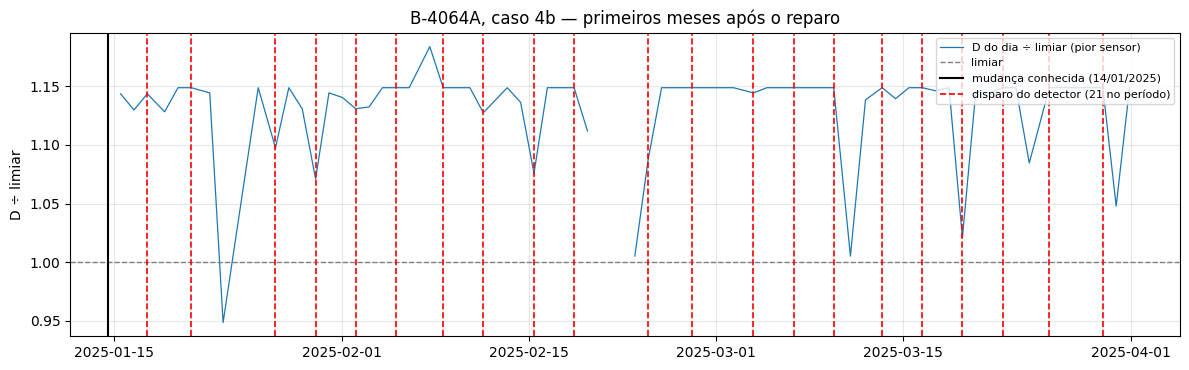

In [8]:
d_diario, disparos = det4.scan(serie4[VOLTA:])
t, s, dias, n = atraso(disparos, VOLTA, serie4.index)
print(f"1º disparo: {t:%d/%m/%Y %H:%M} — {dias:.1f} dias após a volta ({n} amostras) — via {s}")
plot_caso(det4, d_diario, disparos, "B-4064A, caso 4b — primeiros meses após o reparo", VOLTA, fim="2025-04-01")

### Caso 5 — controle sem drift, fora da calibração

O B-4064A só tem ~8 meses de dado antes da falha, então a referência do controle é curta:
calibramos em jan–abr/2024 e varremos mai a 20/ago/2024.

falsos disparos: 2
  28/05/2024 via ['Temperatura Motor LA']
  12/08/2024 via ['Temperatura Motor LA', 'Temperatura Motor LNA']


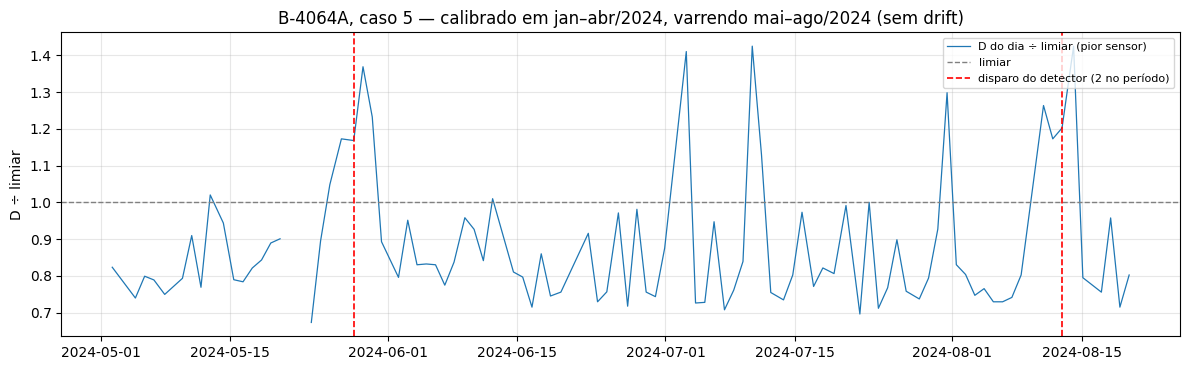

In [9]:
det5 = CalibratedKSDetector(serie4[:"2024-04-30"], window_size=24)
d_diario, disparos = det5.scan(serie4["2024-05-01":"2024-08-20"])
print(f"falsos disparos: {len(disparos)}")
for t, s in disparos: print(f"  {t:%d/%m/%Y} via {s}")
plot_caso(det5, d_diario, disparos, "B-4064A, caso 5 — calibrado em jan–abr/2024, varrendo mai–ago/2024 (sem drift)")

## Comparação com os outros detectores da biblioteca

Resultado de `scripts/compare_drift_detectors.py` (benchmark da biblioteca, sobre o erro de
reconstrução do B-8802B): falsos alarmes em jul–dez/2025 sem drift e atraso no drift real.

In [10]:
csv = PROJECT_ROOT / "results/monitor_drift/compare_drift_detectors.csv"
if csv.exists():
    display(pd.read_csv(csv, index_col=0))
else:
    print("rode: python scripts/compare_drift_detectors.py --csv results/monitor_drift/compare_drift_detectors.csv")

,falsos_alarmes_controle (jul–dez/25),detectou_drift,atraso_amostras,atraso_tempo
detector_name,,,,
ks_calibrado,0,True,1151,4 days 05:05:00
page_hinkley,2,True,1942,6 days 23:15:00
ks_test_w100,400,True,99,0 days 10:45:00
adwin_lite,662,True,50,0 days 06:40:00
ks_test,754,True,49,0 days 06:35:00
psi,846,True,49,0 days 06:35:00
cusum,1982,True,1,0 days 02:35:00


## Resumo

| equipamento | caso | resultado |
|---|---|---|
| B-8802B | 1. drift real (modelo 2022 no dado 2025–26) | 1º disparo **4,2 dias** após a mudança, via Vibração Bomba LA |
| B-8802B | 2. modelo em produção (2025–26) | 3 disparos: 19/05 e 22/05/2025 via Vibração LNA, com a curva praticamente no limiar (mês atípico dentro da própria referência), e 27/06/2026 via Temperatura Bomba LA (a deriva de temperatura que o monitor também aponta no M5) |
| B-8802B | 3. controle fora da calibração (jul–dez/2025) | **0 falsos disparos** |
| B-8802B | regra de persistência, 24 alinhamentos | 3 dias seguidos: 3,4 a 75,7 dias de atraso · **3 de 5: 3,4 a 8,4 dias** (mediana 3,9), 0 falsos nas duas |
| B-4064A | 4a. rampa da falha | não dispara: 2 dias acima do limiar, menos que os 3 exigidos. Esperado: falha é papel do modelo de anomalia |
| B-4064A | 4b. volta do reparo (novo normal) | 1º disparo **3,0 dias** após a volta, via Temperatura Bomba LNA, o mancal que subiu ~20 °C |
| B-4064A | 5. controle fora da calibração (referência de 4 meses) | **2 falsos**, ambos via temperatura do motor, que acompanha o ambiente: a referência curta não cobre a variação sazonal |
| B-8802B | comparação com os detectores da biblioteca | KS calibrado: 0 falsos em 6 meses sem drift · KS por p-valor: 754 · PSI 846 · ADWIN-lite 662 · CUSUM 1.982 · Page–Hinkley 2 |

**Leitura**
- O detector encontra as duas mudanças de conceito conhecidas em 3–4 dias e aponta o sensor certo nos dois equipamentos.
- Falso alarme depende da referência: com 12 meses (B-8802B) não houve nenhum; com 4 meses (B-4064A) apareceram 2, pela sazonalidade da temperatura do motor. A regra da política (referência de 12 meses) vale para o detector também.
- Ele não dispara na rampa curta da falha, e isso é esperado: mudanças de horas a 2 dias ficam com o modelo de anomalia, e o detector cuida de mudanças que persistem por dias.

**Limitação conhecida**: a persistência conta janelas de operação, não dias corridos. Se a série atravessa
uma parada longa (como os 4 meses de manutenção do B-4064A), dias "diferentes" de antes da parada
somam-se aos de depois: começando a varredura antes da falha, o disparo após a volta sai com 1,0 dia em vez de
3,0. Na política isso é coberto pelo gatilho de manutenção (após intervenção, o detector é recalibrado).
Melhoria possível: zerar a contagem de persistência quando houver parada maior que alguns dias.